# 0. Introduction

Dans le cadre de l'IA symbolique, ce projet et notre réalisation s'intéresse à la modélisation du raisonnement d'un agent face à des informations contradictoires. Nous étudions ici les graphes d'argumentation de Dung, un formalisme puissant qui permet d'évaluer la validité de différents arguments en conflit afin de dégager des ensembles de conclusions logiquement cohérentes.

## Imports

In [1]:
import os
import time
import subprocess
import matplotlib.pyplot as plt
import networkx as nx

from src.grounded import grounded_extension
from src.preferred import preferred_extension
from src.stable import stable_extension
from src.check import is_grounded, is_preferred, is_stable
from src.show import show_graph
from src.generate import generate_af
from src.parser import parse_af

# 1. Graph de Dung / Argumentation Framework

Un graphe de Dung (ou Argumentation Framework dans le cadre informatique) est un réseau mathématique simple où les nœuds représentent des arguments et les flèches représentent des relations d'attaque (de conflit) entre eux. L'objectif est d'appliquer des règles logiques sur ce graphe pour déterminer quels arguments peuvent être acceptés ensemble et lesquels doivent être rejetés. C'est un outil intuitif et visuel pour modéliser des débats, des prises de décision ou des résolutions de contradictions en IA.

Voici un exemple simple, qui va nous servir à tester nos solveurs sur un cas basique, et à montrer intuitivement ce que représente les différente sémantique de Dung:

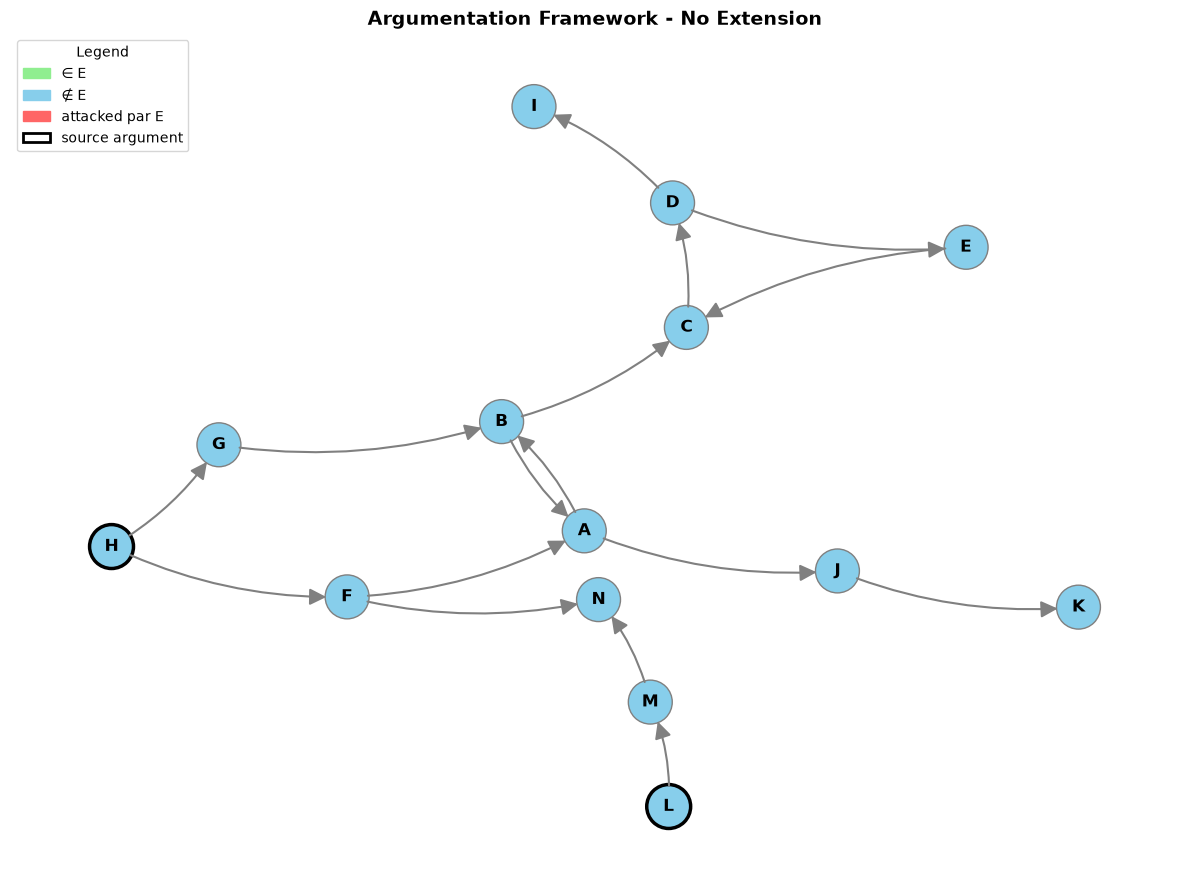

In [2]:
G = nx.DiGraph()
arguments = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N']
attaques = [('A', 'B'), ('A', 'J'), ('B', 'A'), ('B', 'C'), ('C', 'D'), ('D', 'E'), ('D', 'I'), ('E', 'C'), ('F', 'A'), ('F', 'N'), ('G', 'B'), ('H', 'F'), ('H', 'G'), ('J', 'K'), ('L', 'M'), ('M', 'N')]
G.add_nodes_from(arguments)
G.add_edges_from(attaques)

show_graph(G, title="Argumentation Framework - No Extension")

# 2. Extensions

Dans le cadre des graphs d'argumentations de Dung, une extension est un ensemble "cohérent" d'arguments, c'est à dire qu'ils ne se contredisent pas, et sont capables de se défendre contre les attaques des arguments exterieurs. Dung définit alors plusieurs 'sémantiques', qui sont des types d'extensions plus strictes munis de règles suplémentaires, les 4 principales sont:

- <u>Extension Complète (Complete)</u> : C'est un ensemble d'arguments sans conflit interne qui contient (et défend) tous les arguments qu'il est capable de protéger contre les attaques extérieures.
- <u>Extension de Base (Grounded)</u> : C'est l'unique ensemble minimal qui ne prend aucun risque, contenant uniquement les arguments absolument incontestables (le "noyau dur" du consensus).
- <u>Extension Préférée (Preferred)</u> : C'est un ensemble maximal d'arguments cohérents, représentant le plus grand point de vue défendable possible dans le débat.
- <u>Extension Stable (Stable)</u> : C'est un ensemble cohérent d'arguments si fort qu'il attaque et rejette absolument tous les autres arguments extérieurs du graphe.

**<u>NB</u>: Toute extension grounded, et/ou preferred, et/ou stable, est nécessairement complète, nous nous interesseront donc uniquement à ces 3 sémantiqes.**

## Calcul et affichage de différentes sémantiques

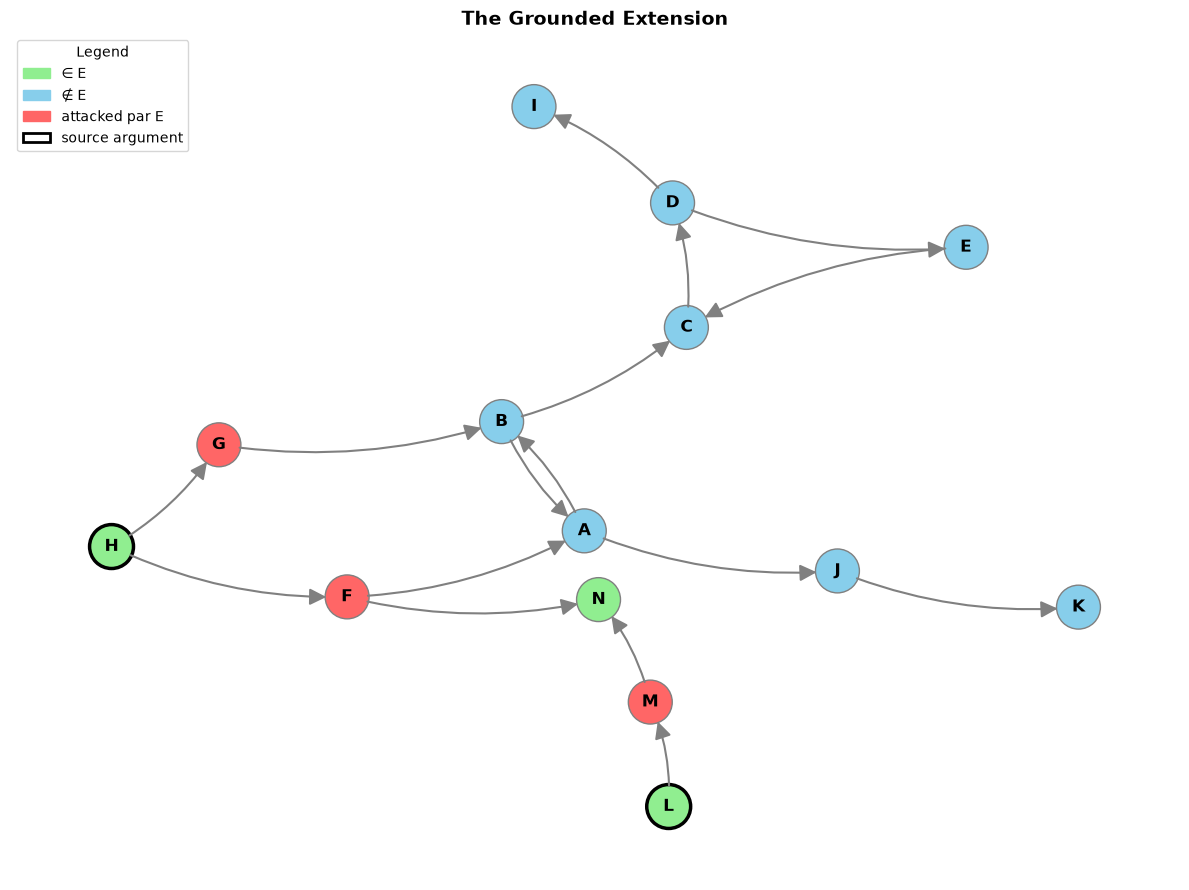

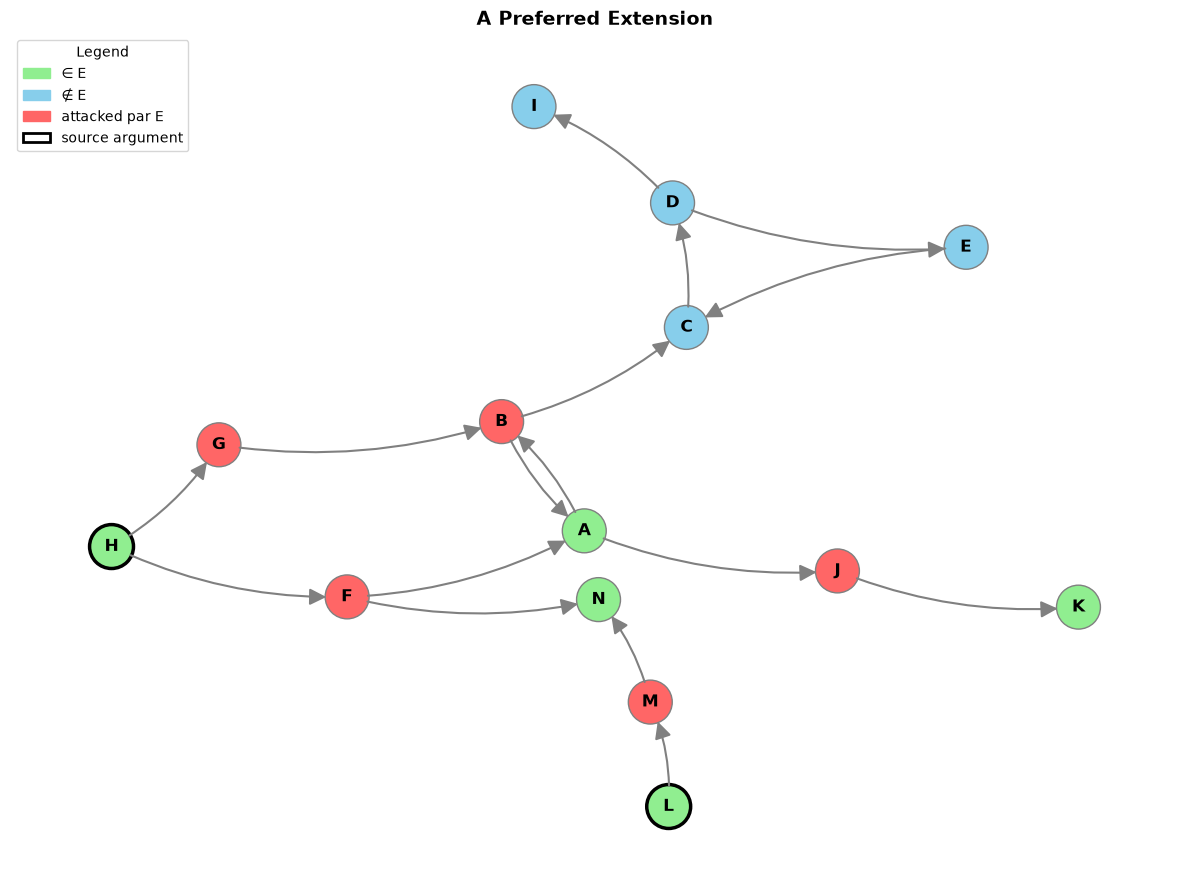

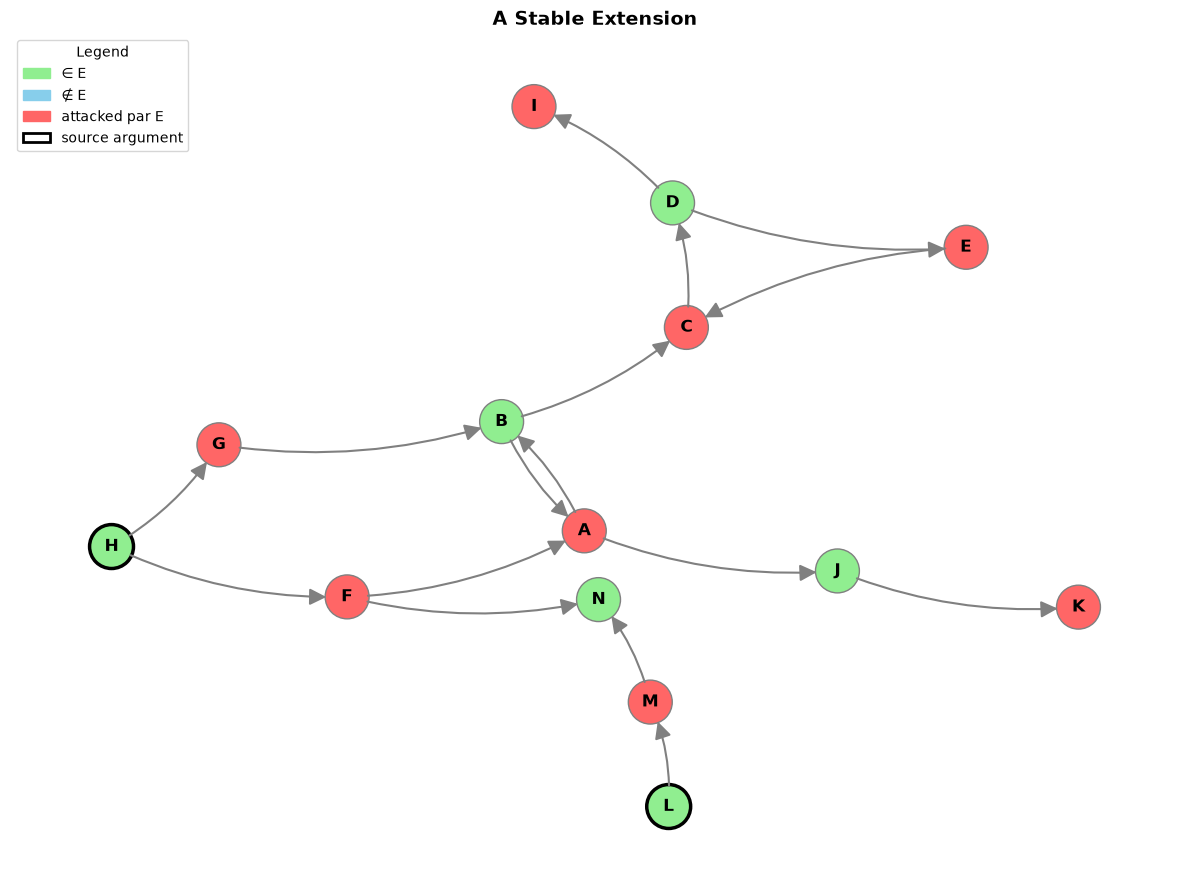

In [ ]:
GR = grounded_extension(G)
PR = preferred_extension(G, 'A') # On veut ici présenter l'extension préférée contenant l'argument A
ST = stable_extension(G)

show_graph(G, GR, "The Grounded Extension")
show_graph(G, PR, "A Preferred Extension")
show_graph(G, ST, "A Stable Extension")

## Intuition géométrique et interprétation

- On observe premièrement que la grounded extension du graph n'est pas vide, grâce à la présence d'arguments sources (arguments jamais contredits), qui propage l'extension en créant des conclusions en chaine sur les arguments qui suivent, jusqu'au niveau de la connexion 'A<->B'.
La partie gauche du graphe est la zone de verité incontestable, elle doit necessairement être incluse dans toutes extensions completes, ou "crédible" en quelque sorte.

- La connexion A<->B arrête la propagation de l'extension grounded, car c'est une attaque mutuelle, équivalente à "ma parole contre la tienne", ainsi cette connexion oblige une prise de décision, indépendament des arguments incontestables.

- L'extension preferred affiché est celle qui choisit de "croire" l'argument A, ainsi on fait un choix et des conclusions se propage sur J et K, c'est une branche de décision.

- Une conséquence de choisir de croire A, est le fait d'invalider B, ce qui a pour conséquence d'isoler le groupe C-D-E-I, hors ce groupe contient un cycle impair. Dans un graphe de Dung, un cycle impair isolé est comme une zone d'état indécis, au arguments de ce cycle de peut être défendu, c'est pour cela que l'extension preferred qui a choisit de croire A ne peut pas trancher et inclure un des arguments C, D, E ou I.

- La derniere extension affichée est stable, elle représente le scenario où l'on choisi de croire B, ce choix se propage alors, et "tranche" sur le cycle impair. Cette fois-ci l'extension contient, ou attaque, tous les noeuds du graphe.

# 3. Performances

Nous allons maintenant analyser les performances de nos solveurs, et les comparer aux performances d'un solveur très efficace issu de la compétition ICCMA 2023, nommé crustabri.

## Affichage

In [4]:
def plot_performance(model, n, s0, step, m):

    # Paramètres fixes pour la génération
    NB_THEMES = 3
    P_INNER = 0.5
    P_OUTER = 0.1
    SEED = 42

    # --- CONFIGURATION DU BENCHMARK ---
    graph_sizes = [s0 + step * i for i in range(n)]
    average_times = []

    # --- MESURE DES TEMPS ---
    for s in graph_sizes:

        total_time = 0
        for i in range(m):
            # 1. Génération du graphe
            graph = generate_af(
                s, 
                NB_THEMES, 
                P_INNER, 
                P_OUTER, 
                SEED
            )
            
            # 2. Chronométrage de la fonction stable_extension
            start_time = time.perf_counter()
            model(graph)
            end_time = time.perf_counter()
        
            # 3. Sauvegarde du temps écoulé (en secondes)
            total_time += end_time - start_time
        
        # 4. Sauvergarde du temps écoulé en moyenne pour les graphs de taille t
        average_time = total_time / m
        average_times.append(average_time)
        print(f"Taille: {s:3d} arguments | Temps Moyen: {average_time:.4f}s")

    # --- AFFICHAGE DU GRAPHIQUE ---
    plt.figure(figsize=(10, 6))
    plt.plot(graph_sizes, average_times, marker='o', linestyle='-', color='b', linewidth=2)

    # Personnalisation des axes et titres
    plt.title(f"{model.__name__}: Average computing time X Number of arguments", fontsize=12, fontweight='bold')
    plt.xlabel("Number of arguments", fontsize=10)
    plt.ylabel("Average computing time (seconds))", fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)

    # Affichage du graphique
    plt.show()

## Notre Modèle

### Stratégie:

Nous avons implémenté plusieurs approches adaptées à la complexité de chaque sémantique :
- **Grounded** : Algorithme de propagation par étiquetage (labelling propagation), structurellement identique à l'algorithme de Kahn pour le tri topologique, adapté aux frameworks d'argumentation.
- **Stable** : Réduction en problème SAT résolu via le moteur CP-SAT de Google OR-Tools. Chaque argument est un booléen et les règles de sémantique sont exprimées sous forme de contraintes logiques.
- **Preferred** : Réduction en problème SAT résolu avec CP-SAT. L'algorithme cherche ensuite itérativement un sur-ensemble admissible de la solution courante jusqu'à ce qu'il n'en existe plus, ce qui garantit que la dernière solution est une extension preferred.


Taille: 100 arguments | Temps Moyen: 0.0000s
Taille: 300 arguments | Temps Moyen: 0.0001s
Taille: 500 arguments | Temps Moyen: 0.0001s
Taille: 700 arguments | Temps Moyen: 0.0002s
Taille: 900 arguments | Temps Moyen: 0.0002s
Taille: 1100 arguments | Temps Moyen: 0.0003s
Taille: 1300 arguments | Temps Moyen: 0.0003s
Taille: 1500 arguments | Temps Moyen: 0.0004s


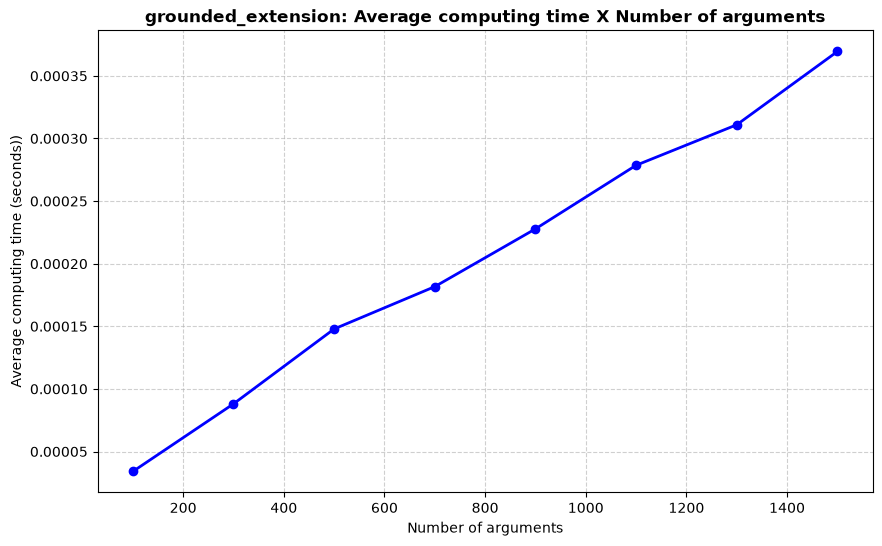

Taille: 100 arguments | Temps Moyen: 0.2103s
Taille: 200 arguments | Temps Moyen: 2.2574s
Taille: 300 arguments | Temps Moyen: 6.2818s
Taille: 400 arguments | Temps Moyen: 15.8293s
Taille: 500 arguments | Temps Moyen: 39.8534s
Taille: 600 arguments | Temps Moyen: 82.6537s
Taille: 700 arguments | Temps Moyen: 252.8886s
Taille: 800 arguments | Temps Moyen: 330.2637s


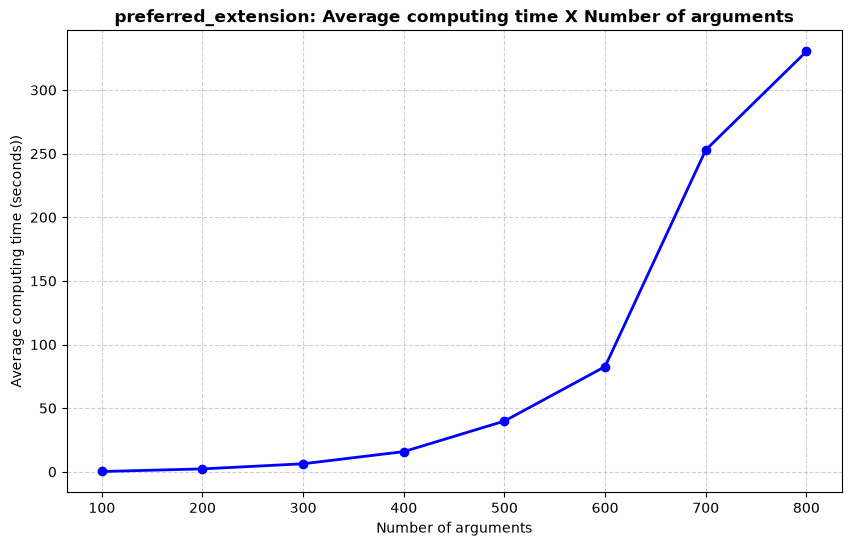

Taille: 100 arguments | Temps Moyen: 0.0285s
Taille: 200 arguments | Temps Moyen: 0.0951s
Taille: 300 arguments | Temps Moyen: 0.5718s
Taille: 400 arguments | Temps Moyen: 3.9644s
Taille: 500 arguments | Temps Moyen: 9.7111s
Taille: 600 arguments | Temps Moyen: 29.0815s
Taille: 700 arguments | Temps Moyen: 52.9728s
Taille: 800 arguments | Temps Moyen: 118.0415s


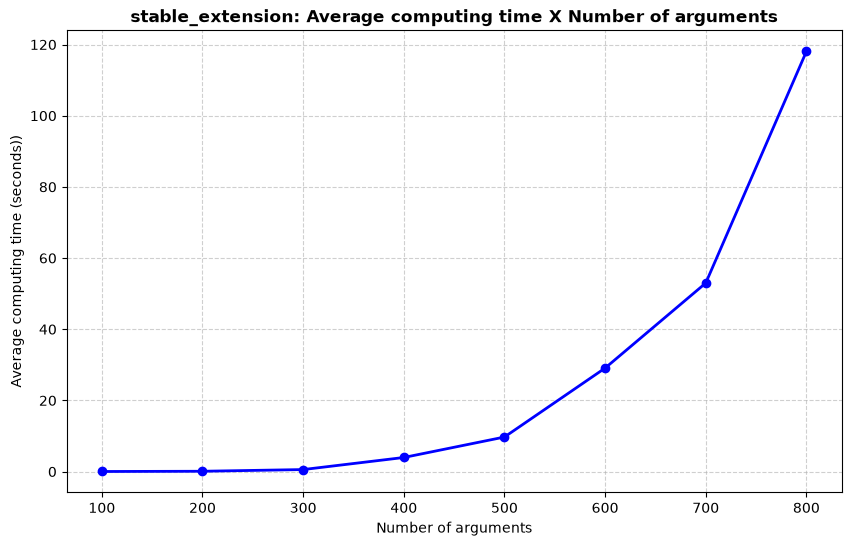

In [5]:
plot_performance(grounded_extension, 8, 100, 200, 20)
plot_performance(preferred_extension, 8, 100, 100, 4)
plot_performance(stable_extension, 8, 100, 100, 5)

# Observations

## Analyse de la complexité

D'après nos graphiques et l'étude théorique :
- **Grounded** : La recherche est très rapide. L'algorithme a une complexité linéaire $\mathcal{O}(n+m)$. C'est un problème de classe **P** très facile.
- **Stable / Preferred** : Le temps d'exécution augmente de manière exponentielle. Décider l'existence de ces extensions est un problème **NP-complet** (ou **NP-difficile** pour la maximisation Preferred). L'utilisation de solveurs SAT optimisés (comme CP-SAT) ou de techniques de pruning, est donc indispensable pour passer à l'échelle.


## 4. Comparaison et Benchmark - compétition ICCMA 2023

Nous avons exploré de nombreuses manières d'utiliser des models issues des particpants de la compétition ICCMA, notamment l'édition 2023, mais malheureusement les models sont en rust et visiblement pas adaptés à un projet python, malgrès nos multiples tentatives de faire un wrapper, pour le model crustarbi par exemple.